<a href="https://colab.research.google.com/github/Ashish2343/R-MoE-Architecture-Comparisions/blob/main/Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install river

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 42.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
import pandas as pd
from river import  preprocessing, compose, metrics, stream, utils, datasets, ensemble, naive_bayes

import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from scipy.stats import linregress
import random

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI Reasearch/CICIDS/Incremental01/final_data1.csv')

In [ ]:
label_encoder = LabelEncoder()
df["Label_encoded"] = label_encoder.fit_transform(df["Label"])

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
sample = df.sample(n=1000, random_state=42)

In [ ]:
df_remaining = df.drop(sample.index)

In [ ]:
X_test = sample.drop(columns=["Label", "Label_encoded"])
y_test = sample["Label_encoded"]

In [ ]:
X = df_remaining.drop(columns=["Label", "Label_encoded"])
y = df_remaining["Label_encoded"]

In [ ]:
def get_holdout_accuracy(dataset_list):
    """Calculates accuracy on a static list without learning."""
    val_metric = metrics.Accuracy()
    for x_val, y_val in dataset_list:
        p_val = model1.predict_one(x_val)
        if p_val is not None:
            val_metric.update(y_val, p_val)
    return val_metric.get()

# **No Drift**

In [ ]:
dataset = stream.iter_pandas(X, y)
val_set_group = list(stream.iter_pandas(X_test, y_test))

In [ ]:
model1 = naive_bayes.GaussianNB()

In [ ]:
WINDOW_SIZE = 5000

acc_metric_1 = utils.Rolling(metrics.Accuracy(), window_size=WINDOW_SIZE)
kappa_metric_1 = utils.Rolling(metrics.CohenKappa(), window_size=WINDOW_SIZE)
rolling_macro_f1 = utils.Rolling(metrics.MacroF1(), window_size=WINDOW_SIZE)

max_acc_g0 = 0.0
max_acc_g1 = 0.0
forgetting_history = []

accuracy_values = []
kappa_values = []
rolling_macro_f1_values = []
timestamps_1 = []
steps = []

log_interval_1 = 1000

In [ ]:
for i, (x, y_true) in enumerate(dataset, start=1):

    y_pred = model1.predict_one(x)

    if y_pred is not None:
        acc_metric_1.update(y_true, y_pred)
        kappa_metric_1.update(y_true, y_pred)
        rolling_macro_f1.update(y_true, y_pred)

    model1.learn_one(x, y_true)

    # -- EVALUATE FORGETTING (Every 1000 steps) ---
    if i % log_interval_1 == 0:

      if len(val_set_group) > 0:
            current_acc = get_holdout_accuracy(val_set_group)
      else:
            current_acc = 0.0


      if current_acc > max_acc_g0: max_acc_g0 = current_acc

      f_max = max(0, max_acc_g0 - current_acc)

      forgetting_history.append(f_max)


      steps.append(i)
      accuracy_values.append(acc_metric_1.get())
      kappa_values.append(kappa_metric_1.get())
      rolling_macro_f1_values.append(rolling_macro_f1.get())

      if i % 50_000 == 0:
          print(f"Step {i} | Acc: {acc_metric_1.get():.3f} | Kappa: {kappa_metric_1.get():.3f}")

Step 50000 | Acc: 0.743 | Kappa: 0.597
Step 100000 | Acc: 0.694 | Kappa: 0.505
Step 150000 | Acc: 0.799 | Kappa: 0.691
Step 200000 | Acc: 0.810 | Kappa: 0.706
Step 250000 | Acc: 0.806 | Kappa: 0.697
Step 300000 | Acc: 0.802 | Kappa: 0.692
Step 350000 | Acc: 0.812 | Kappa: 0.706
Step 400000 | Acc: 0.808 | Kappa: 0.703


In [ ]:
accuracy_values = np.array(accuracy_values)
kappa_values = np.array(kappa_values)
rolling_macro_f1_values = np.array(rolling_macro_f1_values)
forgetting_history = np.array(forgetting_history)
steps = np.array(steps)


# A. Forgetting (Average over the whole experiment)
avg_forgetting = forgetting_history.mean()
final_forgetting = forgetting_history[-1] if len(forgetting_history) > 0 else 0.0

lowest_accuracy  = accuracy_values.min()
highest_accuracy = accuracy_values.max()
average_accuracy = accuracy_values.mean()

lowest_kappa  = kappa_values.min()
highest_kappa = kappa_values.max()
average_kappa = kappa_values.mean()

lowest_rolling_macro_f1  = rolling_macro_f1_values.min()
highest_rolling_macro_f1 = rolling_macro_f1_values.max()
average_rolling_macro_f1 = rolling_macro_f1_values.mean()

#AUC
auc_accuracy = simpson(accuracy_values, dx=1)
auc_kappa = simpson(kappa_values, dx=1)


# Variance (Stability)
accuracy_variance = np.var(accuracy_values)

In [ ]:
print("="*40)
print("NO-DRIFT BASELINE METRICS")
print("="*40)

print(f"Minimum Accuracy:      {lowest_accuracy:.4f}")
print(f"Maximum Accuracy:      {highest_accuracy:.4f}")
print(f"Average Accuracy:      {average_accuracy:.4f}")

print(f"Minimum Kappa:         {lowest_kappa:.4f}")
print(f"Maximum Kappa:         {highest_kappa:.4f}")
print(f"Average Kappa:         {average_kappa:.4f}")

print(f"Minimum Macro F1:      {lowest_rolling_macro_f1:.4f}")
print(f"Maximum Macro F1:      {highest_rolling_macro_f1:.4f}")
print(f"Average Macro F1:      {average_rolling_macro_f1:.4f}")

print(f"AUC (Accuracy):        {auc_accuracy:.2f}")
print(f"AUC (Kappa):           {auc_kappa:.2f}")
print(f"Average Forgetting: {avg_forgetting:.3f}")
print(f"Final Forgetting: {final_forgetting:.3f}")
print(f"Accuracy Variance:     {accuracy_variance:.6f}")

print("\nFinal Rolling Metrics")
print("Accuracy:", acc_metric_1.get())
print("Kappa:   ", kappa_metric_1.get())

print("="*40)

NO-DRIFT BASELINE METRICS
Minimum Accuracy:      0.6600
Maximum Accuracy:      0.8210
Average Accuracy:      0.7842
Minimum Kappa:         0.4264
Maximum Kappa:         0.7212
Average Kappa:         0.6660
Minimum Macro F1:      0.3428
Maximum Macro F1:      0.5486
Average Macro F1:      0.5105
AUC (Accuracy):        339.71
AUC (Kappa):           288.54
Average Forgetting: 0.022
Final Forgetting: 0.121
Accuracy Variance:     0.001540

Final Rolling Metrics
Accuracy: 0.6664
Kappa:    0.5545735522438757


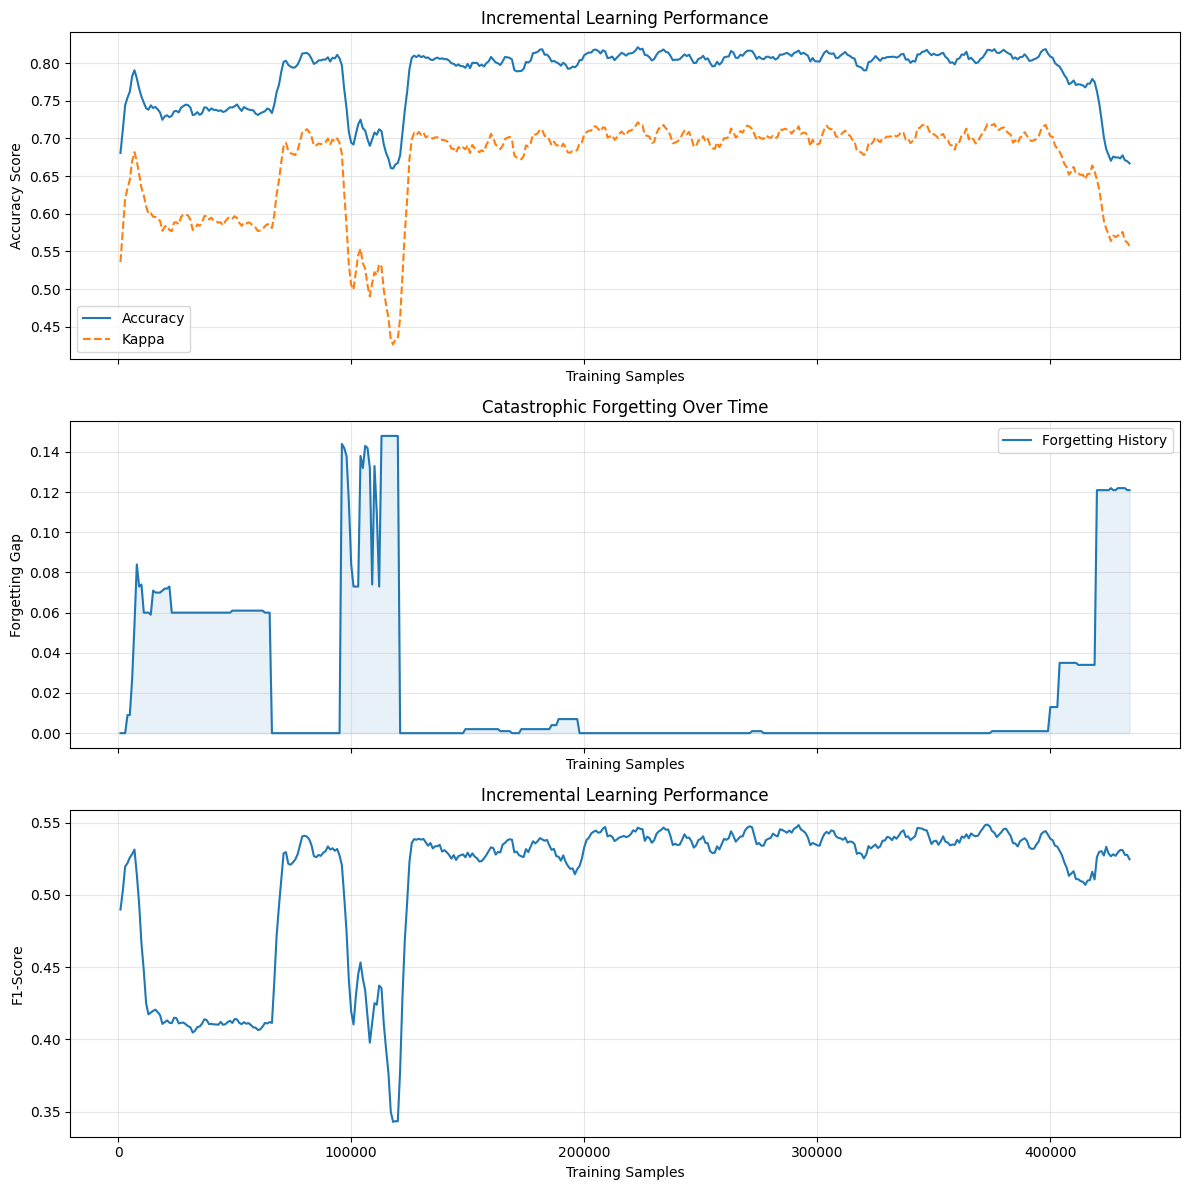

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot 1: Accuracy & Kappa
ax1.plot(steps, accuracy_values, label='Accuracy', color='#1f77b4')
ax1.plot(steps, kappa_values, label='Kappa', color='#ff7f0e', linestyle='--')
ax1.set_ylabel("Accuracy Score")
ax1.set_xlabel("Training Samples")
ax1.set_title("Incremental Learning Performance")
ax1.grid(True, alpha=0.3)



ax1.legend()

# Plot 2: Forgetting
ax2.fill_between(steps, forgetting_history, color='#1f77b4', alpha=0.1)
ax2.plot(steps, forgetting_history, color='#1f77b4', label='Forgetting History')
ax2.set_ylabel("Forgetting Gap")
ax2.set_xlabel("Training Samples")
ax2.set_title("Catastrophic Forgetting Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

# F1-Score
ax3.plot(steps, rolling_macro_f1_values, label='F1', color='#1f77b4')
ax3.set_ylabel("F1-Score")
ax3.set_xlabel("Training Samples")
ax3.set_title("Incremental Learning Performance")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Sudden Drift**

In [ ]:
dataset = stream.iter_pandas(X, y)
val_set_group = list(stream.iter_pandas(X_test, y_test))

In [ ]:
model1 = naive_bayes.GaussianNB()

In [ ]:
Drift_Map = {
    2: ([3], [1.0]),
    3: ([2], [1.0]),

    1: ([1, 0], [0.8, 0.2]),

    0: ([0, 1], [0.8, 0.2]),

    # --- 4. STABILITY (Control Group) ---
    4: ([4], [1.0]),
    5: ([5], [1.0])
}

In [ ]:
WINDOW_SIZE = 5000

acc_metric_1 = utils.Rolling(metrics.Accuracy(), window_size=WINDOW_SIZE)
kappa_metric_1 = utils.Rolling(metrics.CohenKappa(), window_size=WINDOW_SIZE)
rolling_macro_f1 = utils.Rolling(metrics.MacroF1(), window_size=WINDOW_SIZE)

max_acc_g0 = 0.0
max_acc_g1 = 0.0
forgetting_history = []

accuracy_values = []
kappa_values = []
rolling_macro_f1_values = []
timestamps_1 = []
steps = []

log_interval_1 = 1000

DRIFT_POINT = 200000

In [ ]:
for i, (x, y_true) in enumerate(dataset, start=1):

  if (i>=DRIFT_POINT):
    if y_true in Drift_Map:
        candidates, weights = Drift_Map[y_true]

        new_label = random.choices(candidates, weights, k=1)[0]
        y_true = new_label


  y_pred = model1.predict_one(x)

    # 2. Update Metrics
  if y_pred is not None:
      acc_metric_1.update(y_true, y_pred)
      kappa_metric_1.update(y_true, y_pred)
      rolling_macro_f1.update(y_true, y_pred)

  model1.learn_one(x, y_true)

  if i % log_interval_1 == 0:

    acc_old_g0 = get_holdout_accuracy(val_set_group)

    if i < DRIFT_POINT:
      max_acc_g0 = max(max_acc_g0, acc_old_g0)

    f_g0 = max(0, max_acc_g0 - acc_old_g0)

    forgetting_history.append(f_g0)

    steps.append(i)
    accuracy_values.append(acc_metric_1.get())
    kappa_values.append(kappa_metric_1.get())
    rolling_macro_f1_values.append(rolling_macro_f1.get())


  if i % 50_000 == 0:
    print(f"Step {i} | Acc: {acc_metric_1.get():.3f} | Kappa: {kappa_metric_1.get():.3f}")


Step 50000 | Acc: 0.743 | Kappa: 0.597
Step 100000 | Acc: 0.694 | Kappa: 0.505
Step 150000 | Acc: 0.799 | Kappa: 0.691
Step 200000 | Acc: 0.810 | Kappa: 0.706
Step 250000 | Acc: 0.427 | Kappa: 0.319
Step 300000 | Acc: 0.341 | Kappa: 0.259
Step 350000 | Acc: 0.340 | Kappa: 0.260
Step 400000 | Acc: 0.358 | Kappa: 0.277


In [ ]:
# --- 1. Define the Robust Slope Function ---
def get_tangent_recovery_slope(steps, acc_values, drift_point, window_steps=5000):
    steps = np.array(steps)
    acc_values = np.array(acc_values)

    mask_post_drift = steps > drift_point
    steps_post = steps[mask_post_drift]
    acc_post = acc_values[mask_post_drift]

    if len(steps_post) < 2: return None

    min_idx_local = np.argmin(acc_post)
    valley_acc = acc_post[min_idx_local]
    valley_step = steps_post[min_idx_local]


    start_measure = valley_step
    end_measure = valley_step + window_steps

    mask_window = (steps_post >= start_measure) & (steps_post <= end_measure)
    x_reg = steps_post[mask_window]
    y_reg = acc_post[mask_window]

    if len(x_reg) < 2: return None


    slope, intercept, _, _, _ = linregress(x_reg, y_reg)

    return {
        "slope_per_1k": slope * 1000,
        "valley_step": valley_step,
        "valley_acc": valley_acc,
        "plot_x": x_reg,
        "plot_y": slope * x_reg + intercept
    }

In [ ]:
accuracy_values = np.array(accuracy_values)
kappa_values = np.array(kappa_values)
rolling_macro_f1_values = np.array(rolling_macro_f1_values)
forgetting_history = np.array(forgetting_history)
steps = np.array(steps)


# A. Forgetting (Average over the whole experiment)
avg_forgetting = forgetting_history.mean()
final_forgetting = forgetting_history[-1] if len(forgetting_history) > 0 else 0.0

lowest_accuracy  = accuracy_values.min()
highest_accuracy = accuracy_values.max()
average_accuracy = accuracy_values.mean()

lowest_kappa  = kappa_values.min()
highest_kappa = kappa_values.max()
average_kappa = kappa_values.mean()

lowest_rolling_macro_f1  = rolling_macro_f1_values.min()
highest_rolling_macro_f1 = rolling_macro_f1_values.max()
average_rolling_macro_f1 = rolling_macro_f1_values.mean()

#AUC
auc_accuracy = simpson(accuracy_values, dx=1)
auc_kappa = simpson(kappa_values, dx=1)

auc_forgetting = simpson(forgetting_history, dx=1)


# Variance (Stability)
accuracy_variance = np.var(accuracy_values)


# Recovery Slop
slope_results = get_tangent_recovery_slope(steps, accuracy_values, DRIFT_POINT, window_steps=10000)

In [ ]:
print("="*40)
print("SUDDEN DRIFT BASELINE METRICS")
print("="*40)

print(f"Minimum Accuracy of Architecture:      {lowest_accuracy:.4f}")
print(f"Maximum Accuracy of Architecture:      {highest_accuracy:.4f}")
print(f"Average Accuracy of Architecture:      {average_accuracy:.4f}")

print(f"Minimum Kappa of Architecture:         {lowest_kappa:.4f}")
print(f"Maximum Kappa of Architecture:         {highest_kappa:.4f}")
print(f"Average Kappa of Architecture:         {average_kappa:.4f}")

print(f"Minimum Macro F1 of Architecture:      {lowest_rolling_macro_f1:.4f}")
print(f"Maximum Macro F1 of Architecture:      {highest_rolling_macro_f1:.4f}")
print(f"Average Macro F1 of Architecture:      {average_rolling_macro_f1:.4f}")

print(f"AUC (Accuracy):        {auc_accuracy:.2f}")
print(f"AUC (Kappa):           {auc_kappa:.2f}")
print(f"AUC (Forgetting) {auc_forgetting:.2f}")

print(f"Average Forgetting: {avg_forgetting:.3f}")
print(f"Final Forgetting: {final_forgetting:.3f}")
print(f"Accuracy Variance:     {accuracy_variance:.6f}")
print(f"Initial Recovery Speed: {slope_results['slope_per_1k']:.4f} accuracy points per 1k steps")

print("\nFinal Rolling Metrics")
print("Accuracy:", acc_metric_1.get())
print("Kappa:   ", kappa_metric_1.get())

print("="*40)

SUDDEN DRIFT BASELINE METRICS
Minimum Accuracy of Architecture:      0.3380
Maximum Accuracy of Architecture:      0.8182
Average Accuracy of Architecture:      0.5844
Minimum Kappa of Architecture:         0.2567
Maximum Kappa of Architecture:         0.7123
Average Kappa of Architecture:         0.4726
Minimum Macro F1 of Architecture:      0.3142
Maximum Macro F1 of Architecture:      0.5717
Average Macro F1 of Architecture:      0.4156
AUC (Accuracy):        253.00
AUC (Kappa):           204.59
AUC (Forgetting) 86.39
Average Forgetting: 0.199
Final Forgetting: 0.216
Accuracy Variance:     0.037609
Initial Recovery Speed: 0.0011 accuracy points per 1k steps

Final Rolling Metrics
Accuracy: 0.6584
Kappa:    0.5568472598838629


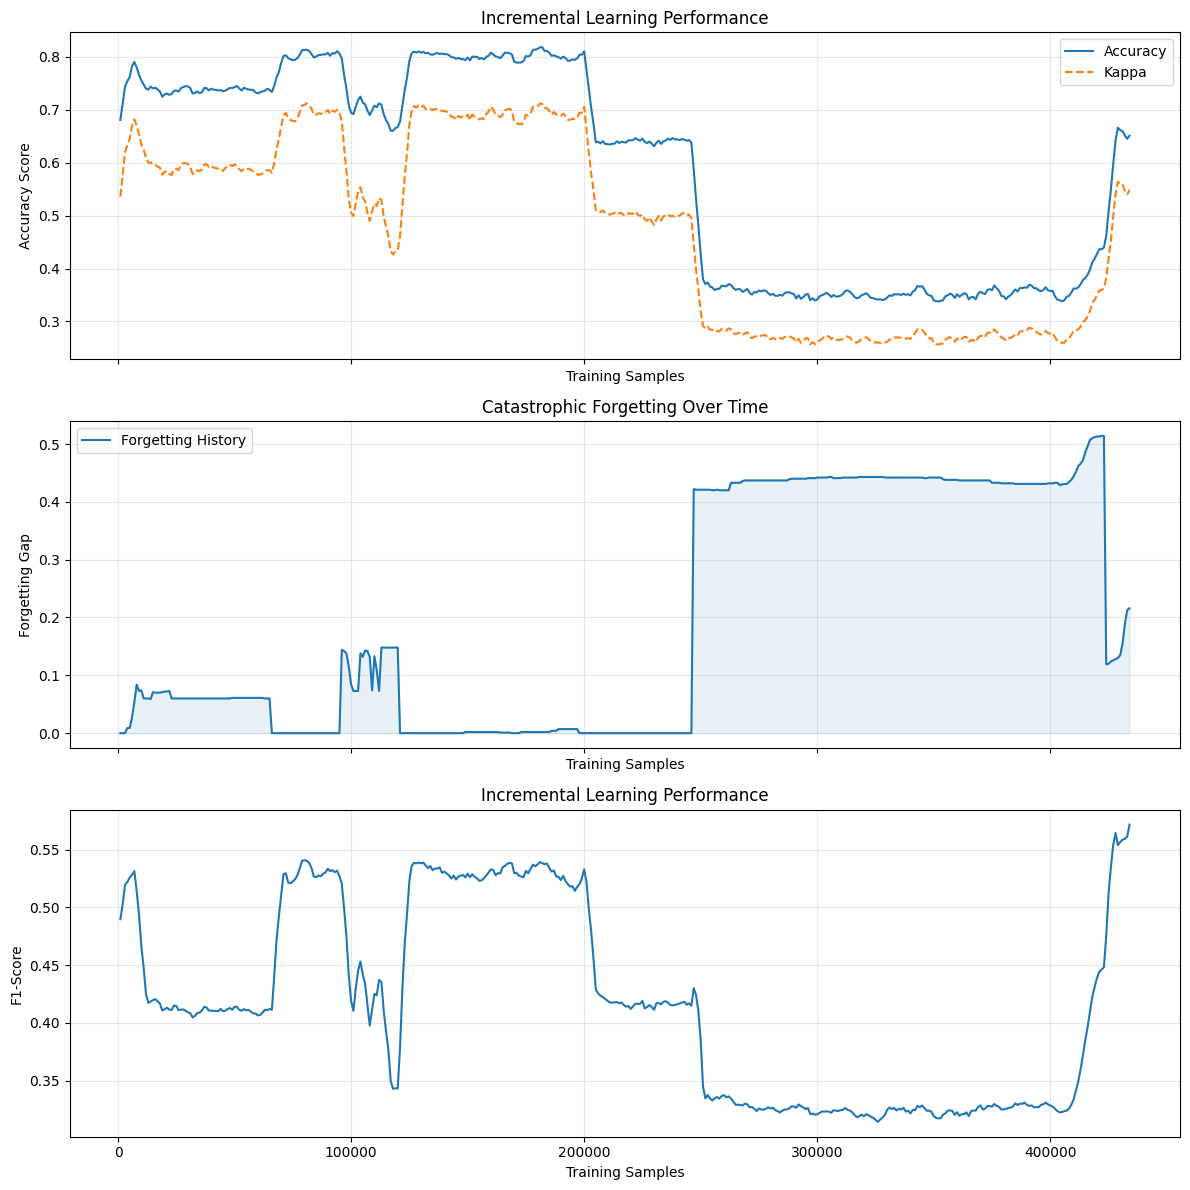

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot 1: Accuracy & Kappa
ax1.plot(steps, accuracy_values, label='Accuracy', color='#1f77b4')
ax1.plot(steps, kappa_values, label='Kappa', color='#ff7f0e', linestyle='--')
ax1.set_ylabel("Accuracy Score")
ax1.set_xlabel("Training Samples")
ax1.set_title("Incremental Learning Performance")
ax1.grid(True, alpha=0.3)



ax1.legend()

# Plot 2: Forgetting
ax2.fill_between(steps, forgetting_history, color='#1f77b4', alpha=0.1)
ax2.plot(steps, forgetting_history, color='#1f77b4', label='Forgetting History')
ax2.set_ylabel("Forgetting Gap")
ax2.set_xlabel("Training Samples")
ax2.set_title("Catastrophic Forgetting Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

# F1-Score
ax3.plot(steps, rolling_macro_f1_values, label='F1', color='#1f77b4')
ax3.set_ylabel("F1-Score")
ax3.set_xlabel("Training Samples")
ax3.set_title("Incremental Learning Performance")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()